Imports 

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [29]:
df = pd.read_csv("house_rent_clean.csv")
print(f" Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head(3)

 Dataset chargé : 2,906 lignes × 17 colonnes


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,rent_per_sqft,floor_number,total_floors,is_ground,month_posted
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,9.09,0,2,1,5
1,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,17.00,1,3,0,5
2,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,12.50,1,2,0,7


Indicateurs Clés (KPIs)

In [30]:
kpis = {
    "Nombre d'annonces" : f"{len(df):,}",
    "Loyer moyen"       : f"₹{df['Rent'].mean():,.0f}",
    "Loyer médian"      : f"₹{df['Rent'].median():,.0f}",
    "Loyer minimum"     : f"₹{df['Rent'].min():,}",
    "Loyer maximum"     : f"₹{df['Rent'].max():,}",
    "Superficie moyenne": f"{df['Size'].mean():.0f} sq ft",
    "Prix moyen/sq ft"  : f"₹{df['rent_per_sqft'].mean():.2f}",
    "Nombre de villes"  : df['City'].nunique(),
}

print("╔══════════════════════════════════════╗")
print("║          INDICATEURS CLÉS            ║")
print("╠══════════════════════════════════════╣")
for k, v in kpis.items():
    print(f"║  {k:<22s} : {str(v):>8s}  ║")
print("╚══════════════════════════════════════╝")

╔══════════════════════════════════════╗
║          INDICATEURS CLÉS            ║
╠══════════════════════════════════════╣
║  Nombre d'annonces      :    2,906  ║
║  Loyer moyen            :  ₹18,929  ║
║  Loyer médian           :  ₹14,000  ║
║  Loyer minimum          :   ₹1,500  ║
║  Loyer maximum          :  ₹78,000  ║
║  Superficie moyenne     : 870 sq ft  ║
║  Prix moyen/sq ft       :   ₹29.67  ║
║  Nombre de villes       :        6  ║
╚══════════════════════════════════════╝


Distributions 

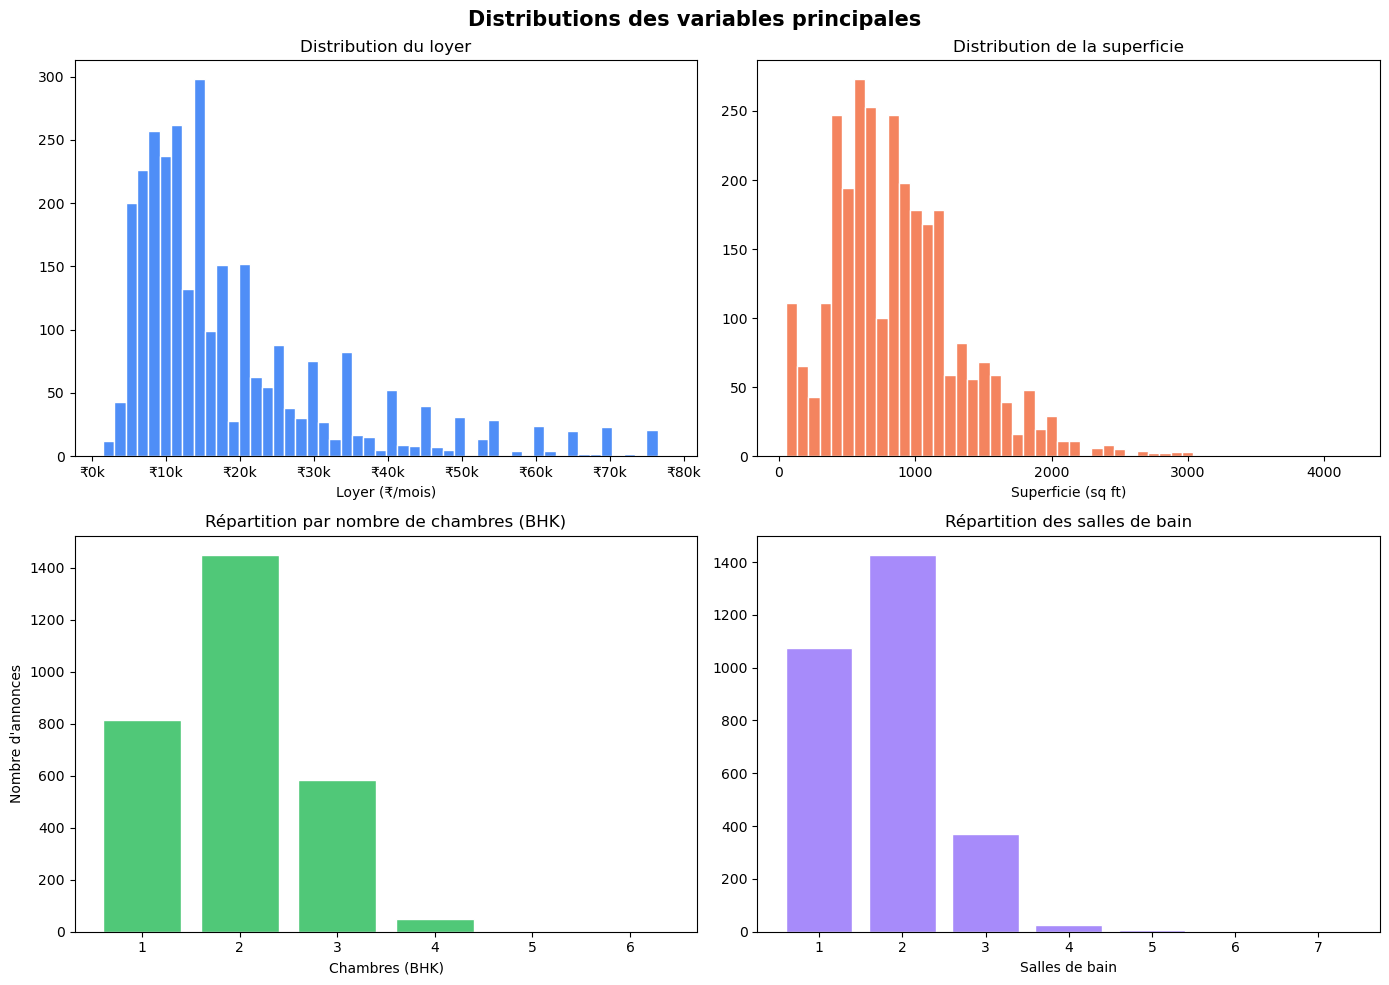

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distributions des variables principales", fontsize=15, fontweight='bold')

# ── Loyer ────────────────────────────────────
axes[0,0].hist(df['Rent'], bins=50, color='#4F8EF7', edgecolor='white')
axes[0,0].set_title('Distribution du loyer')
axes[0,0].set_xlabel('Loyer (₹/mois)')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))

# ── Superficie ───────────────────────────────
axes[0,1].hist(df['Size'], bins=50, color='#F4845F', edgecolor='white')
axes[0,1].set_title('Distribution de la superficie')
axes[0,1].set_xlabel('Superficie (sq ft)')

# ── BHK ──────────────────────────────────────
bhk_counts = df['BHK'].value_counts().sort_index()
axes[1,0].bar(bhk_counts.index, bhk_counts.values, color='#50C878', edgecolor='white')
axes[1,0].set_title('Répartition par nombre de chambres (BHK)')
axes[1,0].set_xlabel('Chambres (BHK)')
axes[1,0].set_ylabel("Nombre d'annonces")

# ── Salles de bain ───────────────────────────
bath_counts = df['Bathroom'].value_counts().sort_index()
axes[1,1].bar(bath_counts.index, bath_counts.values, color='#A78BFA', edgecolor='white')
axes[1,1].set_title('Répartition des salles de bain')
axes[1,1].set_xlabel('Salles de bain')

plt.tight_layout()
plt.show()

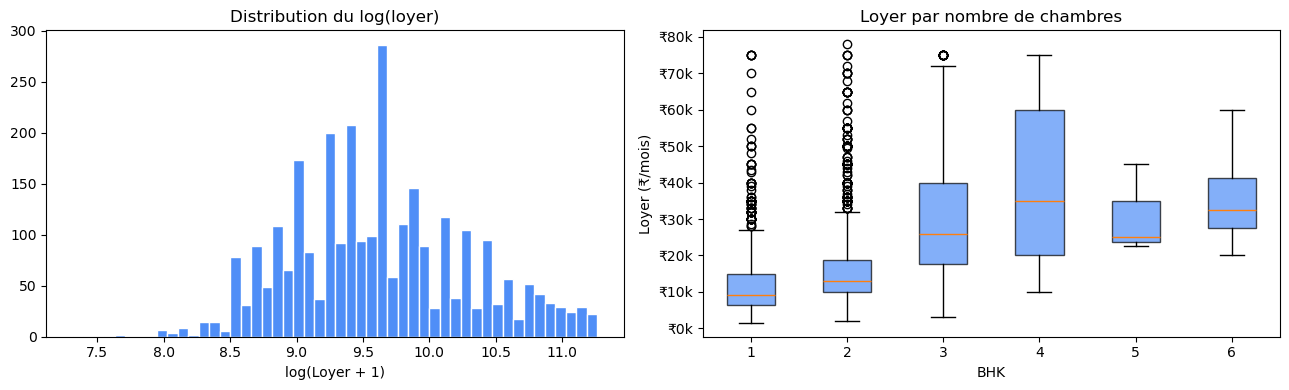

In [33]:
# Log-transformation du loyer (utile pour détecter la distribution)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.log1p(df['Rent']), bins=50, color='#4F8EF7', edgecolor='white')
axes[0].set_title('Distribution du log(loyer)')
axes[0].set_xlabel('log(Loyer + 1)')

axes[1].boxplot([df[df['BHK']==k]['Rent'].dropna() for k in sorted(df['BHK'].unique())],
                labels=sorted(df['BHK'].unique()),
                patch_artist=True,
                boxprops=dict(facecolor='#4F8EF7', alpha=0.7))
axes[1].set_title('Loyer par nombre de chambres')
axes[1].set_xlabel('BHK')
axes[1].set_ylabel('Loyer (₹/mois)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))

plt.tight_layout()
plt.show()

Analyse par Ville

In [34]:
# Statistiques par ville
city_stats = df.groupby('City').agg(
    nb_annonces    = ('Rent', 'count'),
    loyer_moyen    = ('Rent', 'mean'),
    loyer_median   = ('Rent', 'median'),
    loyer_max      = ('Rent', 'max'),
    taille_moyenne = ('Size', 'mean'),
    prix_m2_moyen  = ('rent_per_sqft', 'mean'),
).round(0).sort_values('loyer_median', ascending=False)

print(city_stats.to_string())

           nb_annonces  loyer_moyen  loyer_median  loyer_max  taille_moyenne  prix_m2_moyen
City                                                                                       
Mumbai             324     35978.00      34000.00      78000          592.00          62.00
Delhi              432     19954.00      15000.00      75000          663.00          62.00
Chennai            655     17351.00      14000.00      75000          973.00          18.00
Bangalore          610     17269.00      13500.00      75000          920.00          19.00
Hyderabad          474     17179.00      13000.00      70000         1110.00          20.00
Kolkata            411     11411.00       8500.00      60000          794.00          16.00


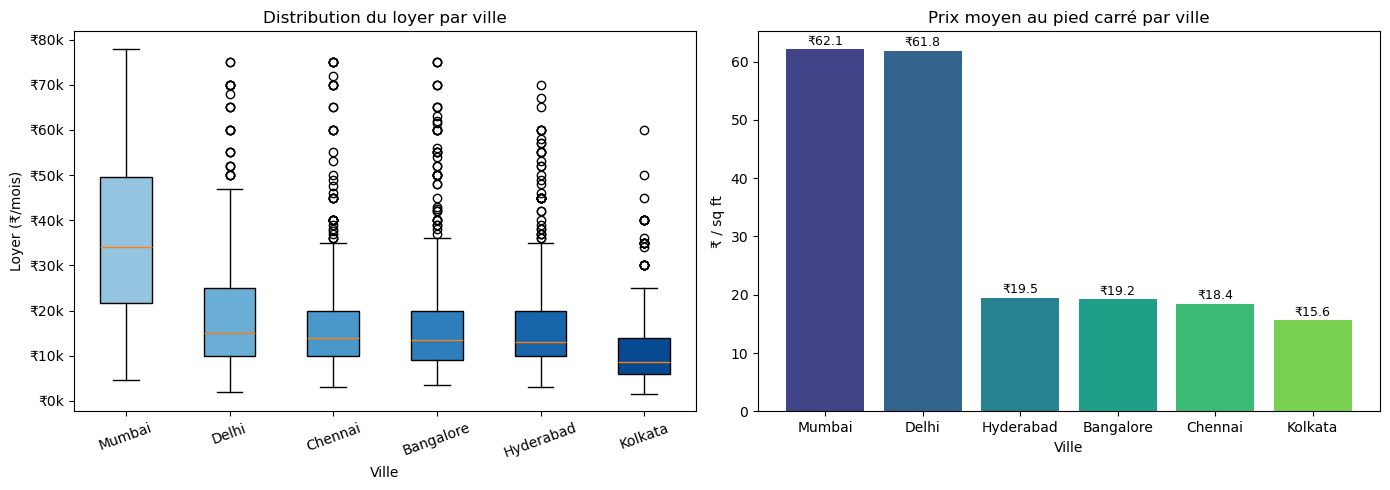

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Boxplot loyer par ville ───────────────────
city_order = df.groupby('City')['Rent'].median().sort_values(ascending=False).index
data_by_city = [df[df['City']==c]['Rent'].values for c in city_order]

bp = axes[0].boxplot(data_by_city, labels=city_order, patch_artist=True, vert=True)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(city_order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_title('Distribution du loyer par ville', fontsize=12)
axes[0].set_xlabel('Ville')
axes[0].set_ylabel('Loyer (₹/mois)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))

# ── Prix au pied carré moyen ─────────────────
ppc = df.groupby('City')['rent_per_sqft'].mean().sort_values(ascending=False)
bars = axes[1].bar(ppc.index, ppc.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(ppc))))
axes[1].set_title('Prix moyen au pied carré par ville', fontsize=12)
axes[1].set_xlabel('Ville')
axes[1].set_ylabel('₹ / sq ft')
for bar, val in zip(bars, ppc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'₹{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Analyse par Meublement & Type de Surface

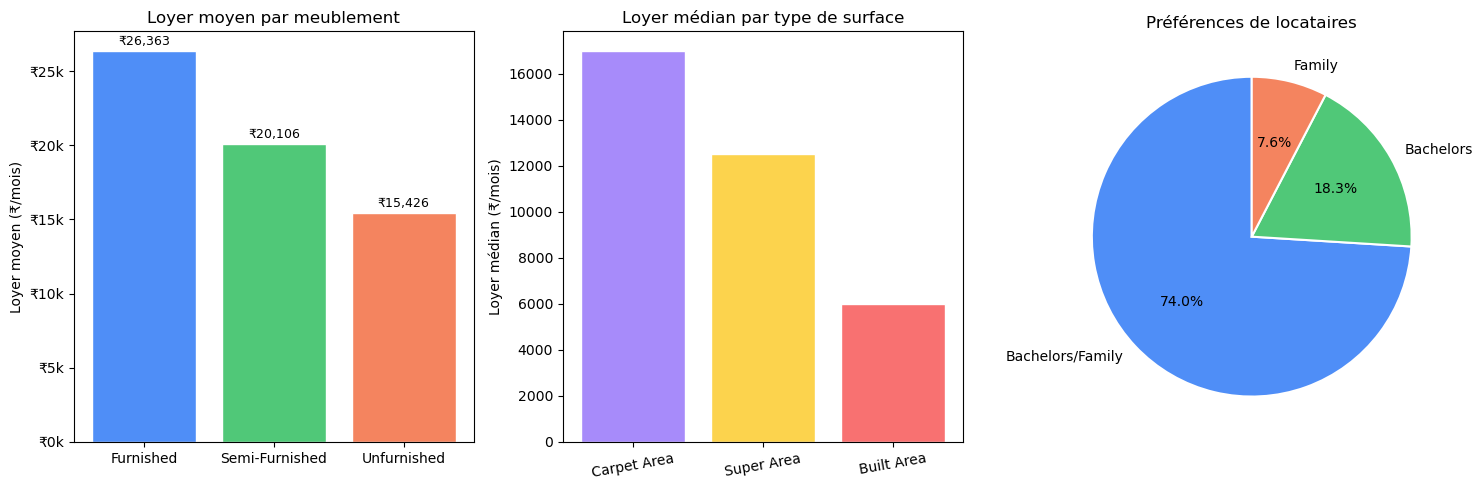

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Meublement : loyer moyen ──────────────────
furn_avg = df.groupby('Furnishing Status')['Rent'].mean().sort_values(ascending=False)
colors_f = ['#4F8EF7', '#50C878', '#F4845F']
bars = axes[0].bar(furn_avg.index, furn_avg.values, color=colors_f, edgecolor='white')
axes[0].set_title('Loyer moyen par meublement', fontsize=12)
axes[0].set_ylabel('Loyer moyen (₹/mois)')
for bar, val in zip(bars, furn_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))

# ── Type de surface : loyer médian ────────────
area_med = df.groupby('Area Type')['Rent'].median().sort_values(ascending=False)
axes[1].bar(area_med.index, area_med.values, color=['#A78BFA', '#FCD34D', '#F87171'],
            edgecolor='white')
axes[1].set_title('Loyer médian par type de surface', fontsize=12)
axes[1].set_ylabel('Loyer médian (₹/mois)')
axes[1].tick_params(axis='x', rotation=10)

# ── Locataire préféré : camembert ────────────
tenant_counts = df['Tenant Preferred'].value_counts()
axes[2].pie(tenant_counts.values, labels=tenant_counts.index, autopct='%1.1f%%',
            colors=['#4F8EF7', '#50C878', '#F4845F', '#A78BFA'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[2].set_title('Préférences de locataires', fontsize=12)

plt.tight_layout()
plt.show()

Corrélations 

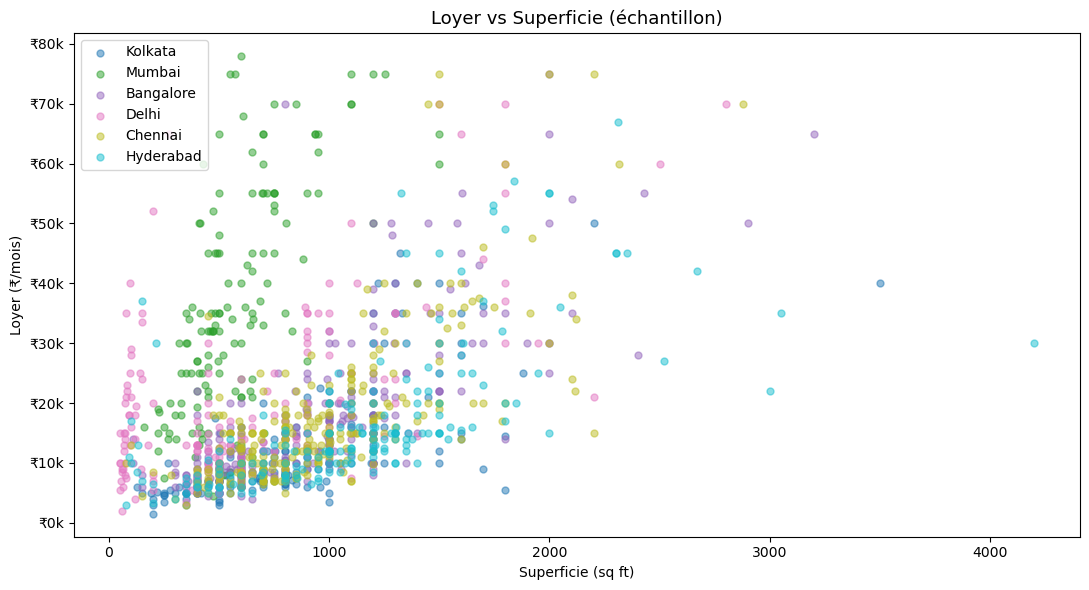

In [41]:
# Nuage de points : Loyer vs Superficie coloré par ville
fig, ax = plt.subplots(figsize=(11, 6))

cities  = df['City'].unique()
palette = plt.cm.tab10(np.linspace(0, 1, len(cities)))
sample  = df.sample(min(1200, len(df)), random_state=42)

for city, color in zip(cities, palette):
    sub = sample[sample['City'] == city]
    ax.scatter(sub['Size'], sub['Rent'], label=city,
               alpha=0.5, s=25, color=color)

ax.set_title('Loyer vs Superficie (échantillon)', fontsize=13)
ax.set_xlabel('Superficie (sq ft)')
ax.set_ylabel('Loyer (₹/mois)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))
ax.legend(loc='upper left', framealpha=0.8)
plt.tight_layout()
plt.show()

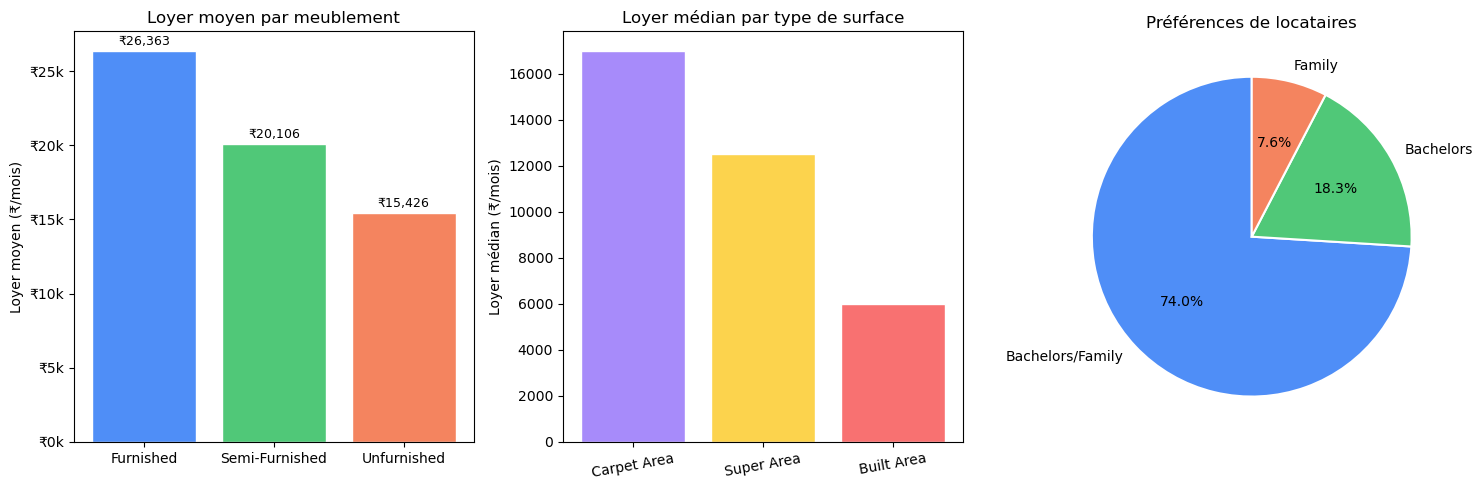

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Meublement : loyer moyen ──────────────────
furn_avg = df.groupby('Furnishing Status')['Rent'].mean().sort_values(ascending=False)
colors_f = ['#4F8EF7', '#50C878', '#F4845F']
bars = axes[0].bar(furn_avg.index, furn_avg.values, color=colors_f, edgecolor='white')
axes[0].set_title('Loyer moyen par meublement', fontsize=12)
axes[0].set_ylabel('Loyer moyen (₹/mois)')
for bar, val in zip(bars, furn_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))

# ── Type de surface : loyer médian ────────────
area_med = df.groupby('Area Type')['Rent'].median().sort_values(ascending=False)
axes[1].bar(area_med.index, area_med.values, color=['#A78BFA', '#FCD34D', '#F87171'],
            edgecolor='white')
axes[1].set_title('Loyer médian par type de surface', fontsize=12)
axes[1].set_ylabel('Loyer médian (₹/mois)')
axes[1].tick_params(axis='x', rotation=10)

# ── Locataire préféré : camembert ────────────
tenant_counts = df['Tenant Preferred'].value_counts()
axes[2].pie(tenant_counts.values, labels=tenant_counts.index, autopct='%1.1f%%',
            colors=['#4F8EF7', '#50C878', '#F4845F', '#A78BFA'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[2].set_title('Préférences de locataires', fontsize=12)

plt.tight_layout()
plt.show()

Analyse Temporelle

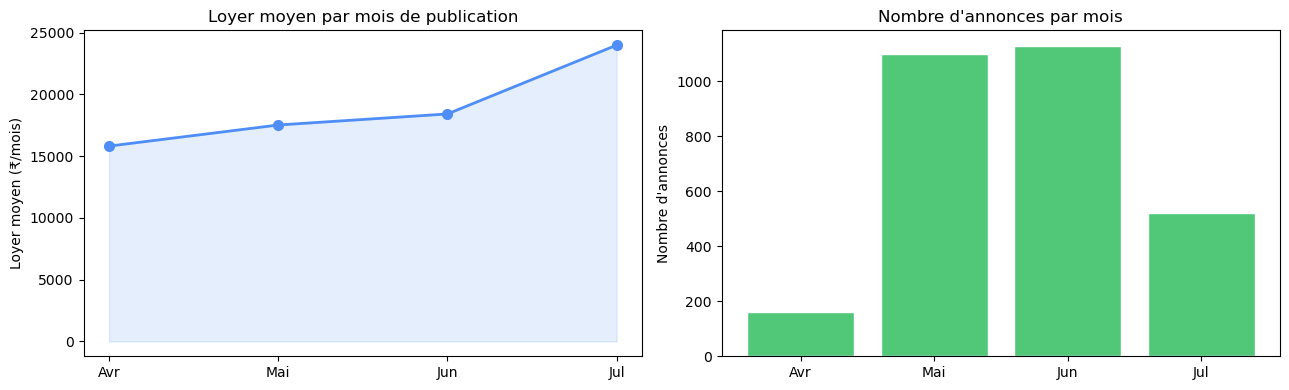

In [42]:
# Évolution du loyer moyen par mois de publication
if 'month_posted' in df.columns:
    month_avg = df.groupby('month_posted')['Rent'].agg(['mean','count']).reset_index()
    month_avg.columns = ['Mois', 'Loyer_moyen', 'Nb_annonces']
    month_names = {1:'Jan',2:'Fév',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
                   7:'Jul',8:'Aoû',9:'Sep',10:'Oct',11:'Nov',12:'Déc'}
    month_avg['Mois_nom'] = month_avg['Mois'].map(month_names)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(month_avg['Mois_nom'], month_avg['Loyer_moyen'],
                 marker='o', color='#4F8EF7', linewidth=2, markersize=7)
    axes[0].fill_between(range(len(month_avg)), month_avg['Loyer_moyen'],
                         alpha=0.15, color='#4F8EF7')
    axes[0].set_xticks(range(len(month_avg)))
    axes[0].set_xticklabels(month_avg['Mois_nom'])
    axes[0].set_title("Loyer moyen par mois de publication")
    axes[0].set_ylabel("Loyer moyen (₹/mois)")

    axes[1].bar(month_avg['Mois_nom'], month_avg['Nb_annonces'],
                color='#50C878', edgecolor='white')
    axes[1].set_title("Nombre d'annonces par mois")
    axes[1].set_ylabel("Nombre d'annonces")

    plt.tight_layout()
    plt.show()
else:
    print("Colonne 'month_posted' non disponible.")